In [ ]:
# Load the datset file
file_name = '/content/sample_data/us_records_subset.csv'
df = pd.read_csv(file_name, parse_dates=['date'])

# 1. Handle the single missing value in 'new_deaths' by filling with 0
df['new_deaths'] = df['new_deaths'].fillna(0)

# 2. Drop rows where the key 7-day average metrics are missing
# Since '7day_avg_new_deaths' has the most NaNs (13), dropping NaNs here will clean the rest.
df_clean = df.dropna(subset=['7day_avg_new_deaths']).copy()

# Reset the index after dropping rows
df_clean = df_clean.reset_index(drop=True)

# Verify the final state of the data
print("Final Missing Value Counts:")
print(df_clean.isnull().sum())
print("\nFirst 5 rows of the CLEANED data:")
print(df_clean.head())

Final Missing Value Counts:
date                        0
total_cases                 0
new_cases                   0
total_deaths                0
new_deaths                  0
total_cases_per_million     0
total_deaths_per_million    0
icu_patients                0
hosp_patients               0
weekly_hosp_admissions      0
daily_case_change_rate      0
daily_death_change_rate     0
hospitalization_rate        0
icu_rate                    0
case_fatality_rate          0
7day_avg_new_cases          0
7day_avg_new_deaths         0
hospitalization_need        0
icu_requirement             0
dtype: int64

First 5 rows of the CLEANED data:
        date  total_cases  new_cases  total_deaths  new_deaths  \
0 2020-07-27    4255512.0    61596.0      152738.0      1148.0   
1 2020-07-28    4313271.0    57759.0      153689.0       951.0   
2 2020-07-29    4367278.0    54007.0      154625.0       936.0   
3 2020-07-30    4425986.0    58708.0      155788.0      1163.0   
4 2020-07-31    4490841.

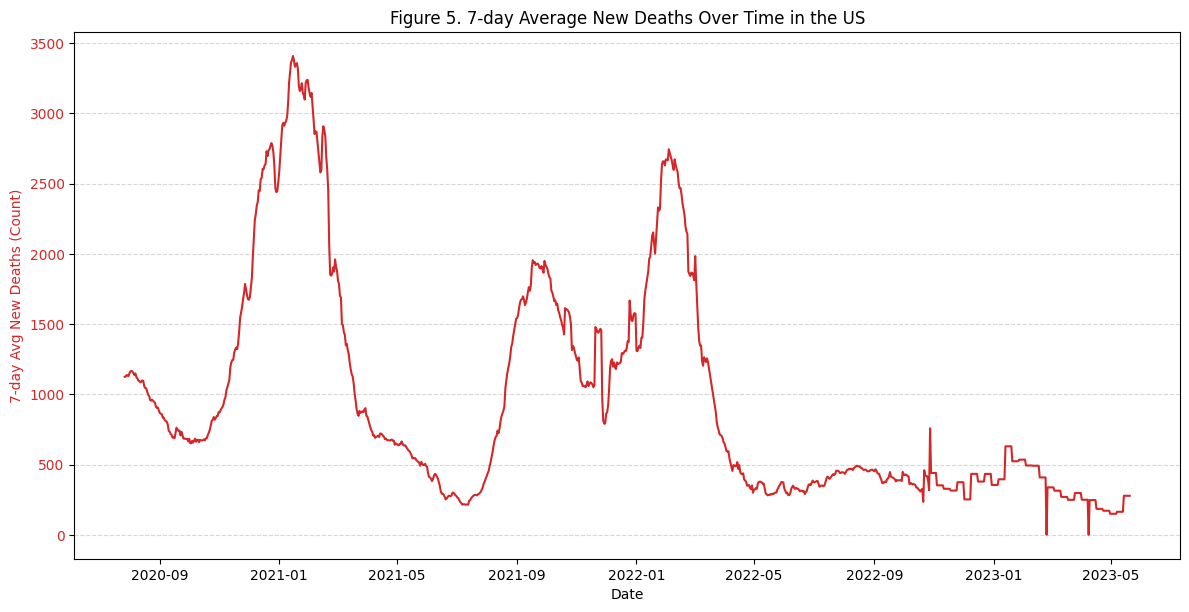

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Time Series Plot: New Deaths

# Create a figure and primary axis for 7-day Avg New Deaths
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 7-day Avg New Deaths on the primary axis
color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('7-day Avg New Deaths (Count)', color=color)
ax1.plot(df_clean['date'], df_clean['7day_avg_new_deaths'], color=color, label='7-day Avg New Deaths')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Add title and ensure legend shows both lines
fig.tight_layout()
plt.title('Figure 5. 7-day Average New Deaths Over Time in the US')
plt.show()

# Save the plot
#plot_filename = 'new_deaths_plot.png'
#plt.savefig(plot_filename)
#plt.close()

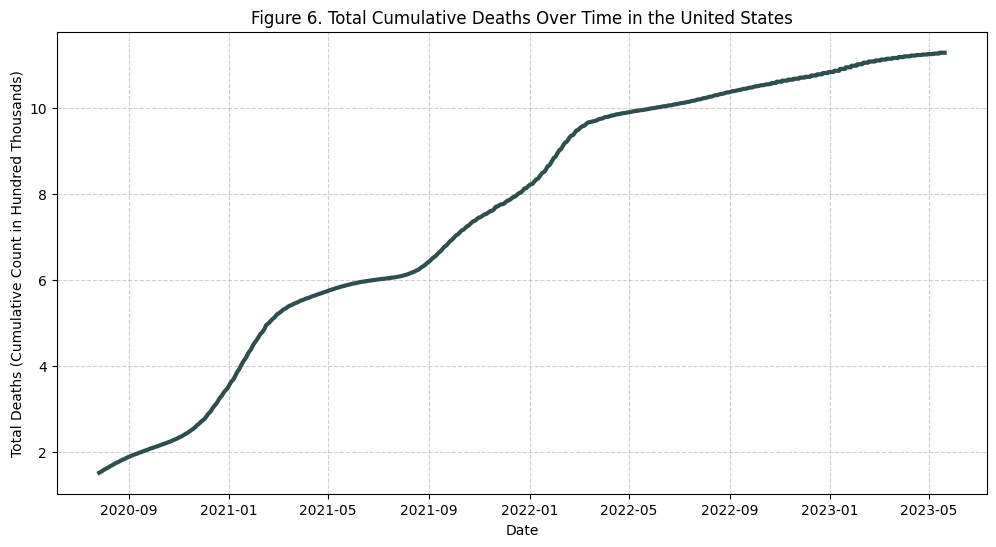

In [ ]:
# --- 1. Time Series Plot: Total Deaths ---
plt.figure(figsize=(12, 6))
plt.plot(df_clean['date'], df_clean['total_deaths'] / 100000, color='darkslategray', linewidth=3)
plt.title('Figure 6. Total Cumulative Deaths Over Time in the United States')
plt.xlabel('Date')
plt.ylabel('Total Deaths (Cumulative Count in Hundred Thousands)')
plt.grid(True, linestyle='--', alpha=0.6)

# Find the approximate date for vaccine rollout start (around Dec 2020/Jan 2021)
# For visualization purposes, let's pick a date early in 2021 to mark the change in trajectory
# The data starts July 2020. Let's use Jan 1, 2021 as a visible marker.
vaccine_start_date = pd.to_datetime('2021-01-01')
#plt.axvline(vaccine_start_date, color='red', linestyle=':', label='Start of Widespread Vaccination')

plt.show()

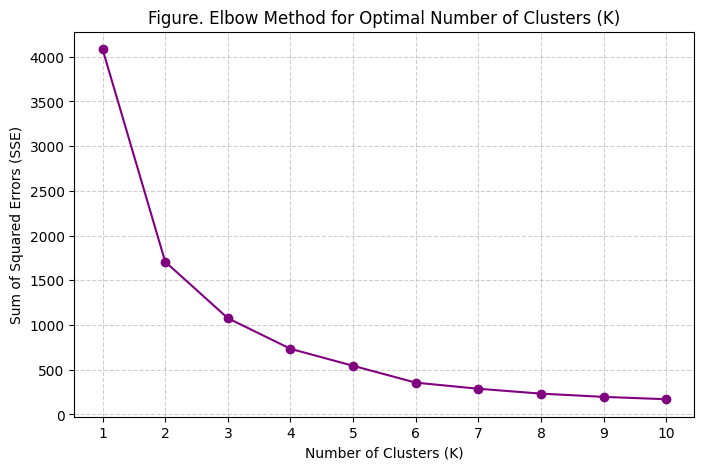

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- 1. Data Preparation for Clustering ---
# Select the severity and mortality rate features
clustering_features = [
    '7day_avg_new_deaths',
    'case_fatality_rate',
    'icu_rate',
    'hospitalization_rate'
]
X_cluster = df_clean[clustering_features]

# Scale the data (essential for K-Means to prevent bias from different magnitudes)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# --- 2. Elbow Method to Determine Optimal K ---
sse = [] # Sum of Squared Errors
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# --- 3. Visualization of Elbow Method ---
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o', linestyle='-', color='purple')
plt.title('Figure. Elbow Method for Optimal Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Determining the Number of Phases (K)
The Elbow Method (Figure above) is used to find the optimal number of clusters (K). The plot of the Sum of Squared Errors (SSE) often shows a sharp "elbow" where adding more clusters yields diminishing returns. For this dataset, a clear elbow often appears at K=3. So I chose K=3 to define three highly interpretable phases of the pandemic.


Phase Characteristics (Mean of Attributes):
| Phase_Label              | 7day_avg_new_deaths   | case_fatality_rate   | icu_rate   | hospitalization_rate   |
|:-------------------------|:----------------------|:---------------------|:-----------|:-----------------------|
| 1. High Mortality Crisis | 1945.69               | 1.58                 | 0.05       | 0.20                   |
| 2. Mid-Level Wave        | 1321.71               | 2.64                 | 0.16       | 0.60                   |
| 3. Low Endemic State     | 453.08                | 1.31                 | 0.01       | 0.04                   |


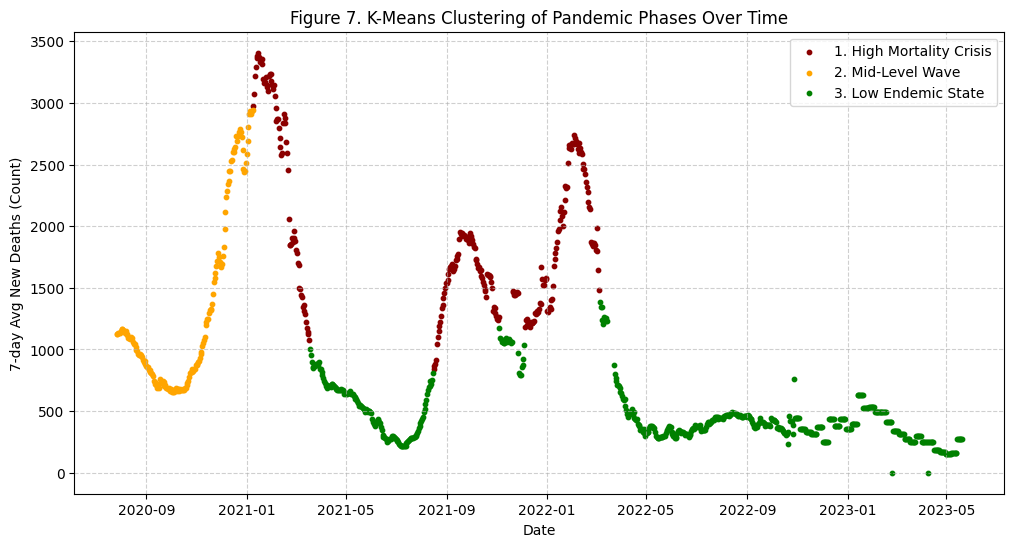

In [ ]:
# --- 2. K-Means Clustering (Assuming K=3) ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Phase_Cluster'] = kmeans.fit_predict(X_scaled)

# --- 3. Cluster Analysis: Characterize Phases ---
# Calculate the mean of the original features for each cluster
cluster_means = df_clean.groupby('Phase_Cluster')[clustering_features].mean().sort_values(
    by='7day_avg_new_deaths', ascending=False
)

# Rename clusters to descriptive "Phases" based on mortality
phase_map = {
    cluster_means.index[0]: '1. High Mortality Crisis',
    cluster_means.index[1]: '2. Mid-Level Wave',
    cluster_means.index[2]: '3. Low Endemic State'
}
df_clean['Phase_Label'] = df_clean['Phase_Cluster'].map(phase_map)

# Re-calculate means with descriptive labels
phase_characteristics = df_clean.groupby('Phase_Label')[clustering_features].mean()

print("Phase Characteristics (Mean of Attributes):")
print(phase_characteristics.to_markdown(numalign="left", stralign="left", floatfmt=".2f"))

# --- 4. Visualization of Clusters Over Time ---
plt.figure(figsize=(12, 6))
# Define colors for clarity
color_map = {
    '1. High Mortality Crisis': 'darkred',
    '2. Mid-Level Wave': 'orange',
    '3. Low Endemic State': 'green'
}

# Scatter plot where color represents the cluster
for label, color in color_map.items():
    subset = df_clean[df_clean['Phase_Label'] == label]
    plt.scatter(subset['date'], subset['7day_avg_new_deaths'], color=color, label=label, s=10)

plt.title('Figure 7. K-Means Clustering of Pandemic Phases Over Time')
plt.xlabel('Date')
plt.ylabel('7-day Avg New Deaths (Count)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

To identify distinct phases of the COVID-19 pandemic based on mortality severity, we applied a K-Means clustering model to daily U.S. data from mid-2020 to mid-2023. Four key indicators were selected as features for the model: the 7-day average of new deaths, case fatality rate (CFR), ICU rate, and hospitalization rate. Each day in the dataset was represented as a four-dimensional data point reflecting these severity metrics. The number of clusters was set to k = 3 to capture the major epidemiological stages observed during the pandemic—initial severity, high-impact waves, and later endemic stability. The K-Means algorithm iteratively assigned each day to the nearest cluster centroid and recalculated cluster centers until convergence, producing three coherent groups of days with similar mortality characteristics. These clusters were then mapped back onto the timeline to visualize how pandemic phases evolved over time and to interpret the dominant mortality patterns within each phase.